# Main Imports

In [2]:
import torch
from torchvision import transforms
import mlflow
from mlflow import MlflowClient
import os
import pandas as pd
import matplotlib.pyplot as plt

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%config InlineBackend.figure_format = 'svg'

In [4]:
os.environ["MLFLOW_TRACKING_URI"] = "https://gitlab.ost.ch/api/v4/projects/15439/ml/mlflow/"
os.environ["MLFLOW_TRACKING_TOKEN"] = ""

In [5]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cuda')

In [6]:
print("Device Info")
print("Selected device:", device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU count:", torch.cuda.device_count())
    print("Current GPU index:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    print("GPU capability:", torch.cuda.get_device_capability())
else:
    print("Running on CPU")

Device Info
Selected device: cuda
CUDA available: True
CUDA version: 12.2
GPU count: 8
Current GPU index: 0
GPU name: Tesla P100-SXM2-16GB
GPU capability: (6, 0)


# Dataset Loader

In [7]:
from torch.utils.data import DataLoader
from social_media_overlay.ext.gebhardt.dataset.CocoCaptions import CocoCaptions

In [8]:
dataset_input_size = 1024  # 1024
dataset_crop_size = 1024  # 1024
dataset_batch_size = 4
dataset_shuffle = False


data_transforms = transforms.Compose([
    transforms.Resize(dataset_input_size),
    transforms.CenterCrop(dataset_crop_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # this will be [-1,1]
])
dataset_coco = CocoCaptions("../data/coco", "val", data_transforms)
data_loader = DataLoader(
    dataset_coco,
    batch_size=dataset_batch_size,
    shuffle=dataset_shuffle,
    #num_workers=0
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

COCO Dataset Debug Info
Root: ../data/coco
Split: val
Annotation file: ../data/coco/annotations/captions_val2017.json
Image directory: ../data/coco/val2017
Root exists ✓
Annotation file exists ✓
Image directory exists ✓
Images found in directory: 5000
Loading annotation metadata...
Entries in image_list: 5000
Dataset initialization finished.


In [9]:
print("Dataset length:", len(dataset_coco))
print("Batch size:", data_loader.batch_size)
print("Shuffle:", dataset_shuffle)
print("Num workers:", data_loader.num_workers)
print("Number of batches per epoch:", len(data_loader))

Dataset length: 5000
Batch size: 4
Shuffle: False
Num workers: 4
Number of batches per epoch: 1250


In [10]:
dataset_coco[0]

(tensor([[[-0.3569, -0.3412, -0.3490,  ...,  0.9451,  0.7647,  0.6471],
          [-0.3804, -0.3647, -0.3647,  ...,  0.9451,  0.7647,  0.6471],
          [-0.4353, -0.4118, -0.4118,  ...,  0.9451,  0.7725,  0.6549],
          ...,
          [-0.4902, -0.4588, -0.3569,  ..., -0.1216, -0.0980, -0.0824],
          [-0.5608, -0.5765, -0.4745,  ..., -0.2392, -0.1686, -0.1137],
          [-0.5922, -0.6314, -0.5294,  ..., -0.2863, -0.2000, -0.1294]],
 
         [[-0.2941, -0.2784, -0.2863,  ...,  0.9137,  0.7333,  0.6157],
          [-0.3176, -0.3020, -0.3098,  ...,  0.9137,  0.7333,  0.6157],
          [-0.3804, -0.3569, -0.3569,  ...,  0.9137,  0.7412,  0.6235],
          ...,
          [-0.4745, -0.4431, -0.3255,  ..., -0.0431, -0.0118,  0.0039],
          [-0.5451, -0.5451, -0.4431,  ..., -0.1451, -0.0745, -0.0196],
          [-0.5765, -0.5922, -0.4902,  ..., -0.1922, -0.1059, -0.0353]],
 
         [[-0.1922, -0.1765, -0.1843,  ...,  0.9216,  0.7412,  0.6235],
          [-0.2235, -0.2078,

# Load Munit Generator

In [11]:
from social_media_overlay.ext.imaginaire.config import Config
from social_media_overlay.ext.imaginaire.generators.munit import Generator

In [12]:
def get_relevant_states(state_dict, use_averaged_model=False):
    # Conditional logic to keep or delete keys
    if use_averaged_model:
        # Keep only keys that contain 'averaged_model'
        filtered_dict = {k.replace("module.", ""): v for k, v in state_dict.items() if 'averaged_model' in k}
    else:
        # Delete keys that contain 'averaged_model'
        filtered_dict = {k.replace("module.", ""): v for k, v in state_dict.items() if 'averaged_model' not in k}

    if "num_updates_tracked" in filtered_dict:
        del filtered_dict["num_updates_tracked"]
    return filtered_dict

In [13]:
cfg = Config("../src/social_media_overlay/ext/imaginaire/imagenet2imagenet.yaml")
gen = Generator(cfg.gen, cfg.data)

state_dict = torch.load("../data/gebhardt/models/imaginaire_munit_200000_s5.pt")

gen_sate_dict = get_relevant_states(state_dict['net_G'])
gen.load_state_dict(gen_sate_dict)
gen = gen.to(device)

## Get Style Dimensions

In [14]:
gen.eval()

# dummy input (ImageNet size typically 256x256)
x = torch.randn(1, 3, 256, 256).to(device)

with torch.no_grad():
    content_a, style_a = gen.autoencoder_a.encode(x)

print("MUNIT Latent Space Info")
print("Content shape:", content_a.shape)
print("Style shape:", style_a.shape)

# extract style dimension
style_dim = style_a.shape[1]
print("Style dimension:", style_dim)

MUNIT Latent Space Info
Content shape: torch.Size([1, 256, 32, 32])
Style shape: torch.Size([1, 8, 1, 1])
Style dimension: 8


# Load Regressor

In [15]:
from social_media_overlay.models.regressor import EmotionRegressor

In [ ]:
path_to_regressor_model = "../data/gebhardt/models/va_pred_all"
regressor = EmotionRegressor(path_to_regressor_model)
regressor.to(device)

# Objective
(R(G(T(s,a),c))-(R(G(s,c))+a))^2
is equal to MSE of regressor value of transformed image by alpha minus the untransformed generated image regressor value plus alpha.

## Replace G(s,c) with source image
(R(G(T(s,a),c))-(R(x_i)+a))^2

In [17]:
from social_media_overlay.models.transformerfunc import SingleDirectionTransformer
from torch.optim.adam import Adam

In [18]:
# ../data/models/singleDirectionTransformer_lr_ganalyze_20260308_200728.pt
saved_path = "style_train_lr_ganalyze_1024_uni_b4_fp32_opos_ep4_20260311_124522.pt"

In [19]:
singleDirectionTransformer = SingleDirectionTransformer(style_dim).to(device)

if saved_path:
    checkpoint = torch.load(saved_path, map_location=device)

    singleDirectionTransformer.load_state_dict(checkpoint["model_state_dict"])

FileNotFoundError: [Errno 2] No such file or directory: 'style_train_lr_ganalyze_1024_uni_b4_fp32_opos_ep4_20260311_124522.pt'

In [ ]:
optimizer = Adam(singleDirectionTransformer.parameters(), lr=0.0002) # lr from ganalyze
if saved_path:
    checkpoint = torch.load(saved_path, map_location=device)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Training

In [ ]:
import json
import time
from pathlib import Path
import matplotlib.pyplot as plt
from itertools import cycle
from torch.nn import MSELoss

In [ ]:
def train(dataloader, model, regressor, generator, loss_fn, optimizer, device):
    size = len(dataloader.dataset)

    model.train()
    regressor.model.eval()
    generator.eval()

    # Freeze generator + regressor parameters
    for p in generator.parameters():
        p.requires_grad = False

    for p in regressor.model.parameters():
        p.requires_grad = False

    # try scaler
    use_amp = False
    amp_enabled = use_amp and device.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    train_losses = []

    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device)
        optimizer.zero_grad(set_to_none=True)  # somehow set to none should reduce memory?

        # Encode image and get original score without gradients
        # https://docs.pytorch.org/docs/stable/generated/torch.no_grad.html
        # Disabling gradient calculation is useful for inference,
        # when you are sure that you will not call Tensor.backward()
        with torch.no_grad():
            original_content, original_style = generator.autoencoder_a.encode(X)

            batch_size = original_style.size(0)
            # reshapes the tensor without copying data
            original_style_flat = original_style.view(batch_size, -1)
            # [B, C, H, W] -> [B, flatten_everything_else]
            # for munit style see above
            # [B, C, H, W] = [B, 8, 1, 1] -> [B, 8]

            original_score = regressor.predict(X)[:, :1]  # only take valence

            # alpha must be in [0, 1] and have shape [B, 1]
            #alpha_min = -original_score
            #alpha_max = 1.0 - original_score
            #alpha = alpha_min + torch.rand_like(original_score) * (alpha_max - alpha_min)
            alpha = torch.empty_like(original_score).uniform_(0, 0.5)
        # when amp enabled use floating point 16!
        with torch.cuda.amp.autocast(enabled=amp_enabled):

            # Transform style
            transformed_style_flat = model.transform(
                z=original_style_flat,
                step_sizes=alpha
            )

            # Reshape back to original style shape
            transformed_style = transformed_style_flat.view_as(original_style)

            # Decode transformed image
            transformed_images = generator.autoencoder_a.decode(
                original_content,
                transformed_style
            )

            # Regress transformed image
            # DO NOT use no_grad here, since gradients must flow to transformed_images -> model
            transformed_outputs = regressor.forward(transformed_images)
            transformed_images_score = transformed_outputs[:, :1]  # -> [B,1]

            # Target
            target_score = original_score + alpha

            if transformed_images_score.dim() != 2 or transformed_images_score.shape[1] != 1:
                raise RuntimeError(
                    f"Expected regressor output shape [B,1], got {transformed_images_score.shape}"
                )
            if target_score.dim() != 2 or target_score.shape[1] != 1:
                raise RuntimeError(
                    f"Expected target_score shape [B,1], got {target_score.shape}"
                )
            if transformed_images_score.shape[0] != target_score.shape[0]:
                raise RuntimeError(
                    f"Batch mismatch: pred {transformed_images_score.shape} vs target {target_score.shape}"
                )

            # Loss
            loss = loss_fn(transformed_images_score, target_score)

        # Backprop
        if amp_enabled:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        train_losses.append(loss.item())

        # Backprop
        #loss.backward()
        #optimizer.step()

        if batch % 100 == 0:
            current = (batch + 1) * len(X)
            mlflow.log_metric("train/loss", loss.item(), step=batch)

            if torch.cuda.is_available():
                mlflow.log_metric(
                    "system/gpu_memory_allocated_gb",
                    torch.cuda.memory_allocated() / 1024**3, step=batch
                )
                mlflow.log_metric(
                    "system/gpu_memory_reserved_gb",
                    torch.cuda.memory_reserved() / 1024**3, step=batch
                )

            print(f"######################################loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")
            print(f"org mean: {original_score.mean().item():.4f}")
            print(f"trans mean: {transformed_images_score.mean().item():.4f}")
            print(f"alpha mean: {alpha.mean().item():.4f}")
            if torch.cuda.is_available():
                print(
                    "allocated:",
                    torch.cuda.memory_allocated() / 1024**3, "GB"
                )
                print(
                    "reserved :",
                    torch.cuda.memory_reserved() / 1024**3, "GB"
                )
    return train_losses

In [ ]:
def predict_loss(dataloader, model, regressor, generator, loss_fn, device):
    model.eval()
    regressor.model.eval()
    generator.eval()

    test_loss = 0
    num_batches = len(dataloader)

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)

            # Encode
            original_content, original_style = generator.autoencoder_a.encode(X)

            batch_size = original_style.size(0)
            original_style_flat = original_style.view(batch_size, -1)

            # Original score
            original_score = regressor.predict(X)[:, :1]

            # Random alpha
            alpha_min = -original_score
            alpha_max = 1.0 - original_score
            alpha = alpha_min + torch.rand_like(original_score) * (alpha_max - alpha_min)

            # Transform style
            transformed_style_flat = model.transform(
                z=original_style_flat,
                step_sizes=alpha
            )

            transformed_style = transformed_style_flat.view_as(original_style)

            # Decode image
            transformed_images = generator.autoencoder_a.decode(
                original_content,
                transformed_style
            )

            # Predict score
            outputs = regressor.forward(transformed_images)
            transformed_score = outputs[:, :1]

            # Target
            target_score = original_score + alpha

            # Loss
            loss = loss_fn(transformed_score, target_score)
            test_loss += loss.item()

    test_loss /= num_batches

    print(f"Test Error: Avg loss: {test_loss:.6f}")

    return test_loss

In [42]:
import gc
import time
from datetime import datetime

experiment_name = "style_train_lr_ganalyze_1024_uni_b4_fp32_opos_ep5"

client = MlflowClient()

try:
    experiment_id = client.create_experiment(
        name=experiment_name,
        tags={"project": "style-transform"}
    )
except Exception:
    experiment_id = client.get_experiment_by_name(experiment_name).experiment_id

loss_fn = MSELoss() # gemäss GANalyze

epochs = 1
steps_per_epoch = len(data_loader)
total_planned_steps = epochs * steps_per_epoch

run_start_time = time.perf_counter()
run_start_datetime = datetime.utcnow().isoformat()

completed_epochs = 0
completed_steps = 0
interrupted = False

all_losses = []

try:
    with mlflow.start_run(experiment_id=experiment_id):
        # Params
        mlflow.log_param("batch_size", data_loader.batch_size)
        mlflow.log_param("optimizer", type(optimizer).__name__)
        mlflow.log_param("loss_fn", type(loss_fn).__name__)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("steps_per_epoch", steps_per_epoch)
        mlflow.log_param("total_planned_steps", total_planned_steps)
        mlflow.log_param("amp", True)
        mlflow.log_param("model_class", type(singleDirectionTransformer).__name__)
        mlflow.log_param("device", str(device))

        # Optional model size info
        total_params = sum(p.numel() for p in singleDirectionTransformer.parameters())
        trainable_params = sum(p.numel() for p in singleDirectionTransformer.parameters() if p.requires_grad)
        mlflow.log_param("total_parameters", total_params)
        mlflow.log_param("trainable_parameters", trainable_params)

        # Tags
        mlflow.set_tag("project", "style-transform")
        mlflow.set_tag("run_started_utc", run_start_datetime)

        for t in range(epochs):
            epoch_num = t + 1
            epoch_start_time = time.perf_counter()

            print(f"Epoch {epoch_num}\n-------------------------------")

            epoch_losses = train(
                data_loader,
                singleDirectionTransformer,
                regressor,
                gen,
                loss_fn,
                optimizer,
                device
            )

            all_losses.extend(epoch_losses)

            epoch_duration_sec = time.perf_counter() - epoch_start_time
            completed_epochs += 1
            completed_steps += steps_per_epoch

            mlflow.log_metric("epoch_duration_sec", epoch_duration_sec, step=epoch_num)
            mlflow.log_metric("completed_epochs", completed_epochs, step=epoch_num)
            mlflow.log_metric("completed_steps", completed_steps, step=epoch_num)

        print("Done!")

except KeyboardInterrupt:
    interrupted = True
    print("\nTraining interrupted.")

finally:
    total_duration_sec = time.perf_counter() - run_start_time

    # Log final status if a run is still active
    active_run = mlflow.active_run()
    if active_run is not None:
        mlflow.log_metric("total_duration_sec", total_duration_sec)
        mlflow.log_metric("completed_epochs_final", completed_epochs)
        mlflow.log_metric("completed_steps_final", completed_steps)

        if total_duration_sec > 0:
            mlflow.log_metric("steps_per_sec", completed_steps / total_duration_sec)
            mlflow.log_metric("epochs_per_sec", completed_epochs / total_duration_sec)

        mlflow.set_tag("status", "interrupted" if interrupted else "finished")

        if torch.cuda.is_available():
            mlflow.log_metric("cuda_memory_allocated_mb", torch.cuda.memory_allocated() / 1024**2)
            mlflow.log_metric("cuda_memory_reserved_mb", torch.cuda.memory_reserved() / 1024**2)

    print("Cleaning GPU memory...")
    torch.cuda.empty_cache()
    gc.collect()

Epoch 1
-------------------------------
######################################loss: 0.078662  [    4/ 5000]
org mean: 0.4740
trans mean: 0.4686
alpha mean: 0.2383
allocated: 1.6944079399108887 GB
reserved : 10.453125 GB
######################################loss: 0.039392  [  404/ 5000]
org mean: 0.6342
trans mean: 0.6225
alpha mean: 0.1656
allocated: 1.6947436332702637 GB
reserved : 12.8046875 GB
######################################loss: 0.122306  [  804/ 5000]
org mean: 0.5995
trans mean: 0.5919
alpha mean: 0.3050
allocated: 1.6940112113952637 GB
reserved : 12.806640625 GB
######################################loss: 0.073631  [ 1204/ 5000]
org mean: 0.5381
trans mean: 0.5446
alpha mean: 0.2366
allocated: 1.6940112113952637 GB
reserved : 12.806640625 GB
######################################loss: 0.055635  [ 1604/ 5000]
org mean: 0.5847
trans mean: 0.5992
alpha mean: 0.2155
allocated: 1.6947436332702637 GB
reserved : 12.806640625 GB
######################################loss: 0.0703

In [36]:
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
path = f"../data/models/{experiment_name}_{timestamp}.pt"

torch.save({
    "model_state_dict": singleDirectionTransformer.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
}, path)

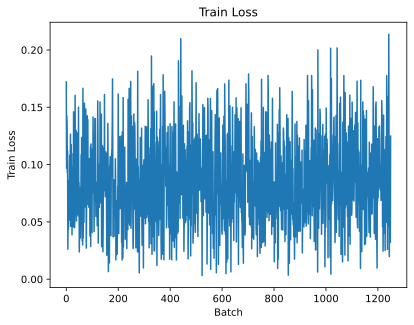

In [37]:
plt.plot(all_losses)
plt.xlabel("Batch")
plt.ylabel("Train Loss")
plt.title("Train Loss")
plt.savefig(f"{experiment_name}_loss.svg", format="svg")
plt.show()

In [39]:
# plus
singleDirectionTransformer._parameters

OrderedDict([('w',
              Parameter containing:
              tensor([[-0.5554,  0.1750,  0.7928, -0.4493,  0.9482,  1.0543, -0.9477,  0.2689]],
                     device='cuda:0', requires_grad=True))])

In [49]:
singleDirectionTransformer._parameters

OrderedDict([('w',
              Parameter containing:
              tensor([[-0.2597,  0.8993, -0.7579,  0.3405, -1.2580,  0.3164,  1.4017,  1.6364]],
                     device='cuda:0', requires_grad=True))])

# Generation

In [27]:
def generate_images(X, model, generator, device, alphas):
    model.eval()
    generator.eval()
    transformed_images = []

    with torch.no_grad():
        X = X.to(device)

        # Encode
        original_content, original_style = generator.autoencoder_a.encode(X)

        batch_size = original_style.size(0)
        original_style_flat = original_style.view(batch_size, -1)

        # Transform style
        transformed_style_flat = model.transform(
            z=original_style_flat,
            step_sizes=alphas
        )

        transformed_style = transformed_style_flat.view_as(original_style)

        # Decode image
        transformed_images = generator.autoencoder_a.decode(
            original_content,
            transformed_style
        )

    return transformed_images

In [51]:
def denorm(x):
    return (x.clamp(-1, 1) + 1) / 2

alphas = [0.0, -0.1, -0.25, -0.5, -1]

def get_first_n_images(dataloader, n=8):
    imgs = []
    for batch in dataloader:
        x = batch[0] if isinstance(batch, (list, tuple)) else batch
        for img in x:
            imgs.append(img)
            if len(imgs) == n:
                return torch.stack(imgs)
    return torch.stack(imgs)


X8 = get_first_n_images(data_loader, n=8)
X8_device = X8.to(device)

singleDirectionTransformer.eval()
gen.eval()
regressor.model.eval()

outputs = []
scores_list = []

with torch.no_grad():
    original_scores = regressor.predict(X8_device).detach().cpu()

    for alpha in alphas:
        alpha_tensor = torch.full((X8_device.size(0),), alpha, device=device)

        out = generate_images(X8_device, singleDirectionTransformer, gen, device, alpha_tensor)
        outputs.append(out.cpu())

        scores = regressor.predict(out.to(device)).detach().cpu()
        scores_list.append(scores)

# identity reference = alpha 0.0
identity_idx = alphas.index(0.0)
identity_outputs = outputs[identity_idx]
identity_scores = scores_list[identity_idx]

rows = X8.size(0)
cols = len(alphas) + 1

fig, axes = plt.subplots(rows, cols, figsize=(3.8 * cols, 3.6 * rows))

if rows == 1:
    axes = axes[None, :]

for r in range(rows):
    # original image
    ax = axes[r, 0]
    img = denorm(X8[r]).permute(1, 2, 0).cpu().numpy()

    v_orig = original_scores[r, 0].item()
    a_orig = original_scores[r, 1].item()

    v_id = identity_scores[r, 0].item()
    a_id = identity_scores[r, 1].item()

    dv_orig_id = v_orig - v_id
    da_orig_id = a_orig - a_id

    ax.imshow(img)
    ax.set_title(
        f"original\nv={v_orig:.3f}, a={a_orig:.3f}\nΔid v={dv_orig_id:+.3f}, a={da_orig_id:+.3f}",
        fontsize=10
    )
    ax.axis("off")

    # generated images
    for c, alpha in enumerate(alphas, start=1):
        ax = axes[r, c]
        img = denorm(outputs[c - 1][r]).permute(1, 2, 0).cpu().numpy()

        v = scores_list[c - 1][r, 0].item()
        a = scores_list[c - 1][r, 1].item()

        dv = v - v_id
        da = a - a_id

        label = "identity" if alpha == 0.0 else f"α={alpha}"

        ax.imshow(img)
        ax.set_title(
            f"{label}\nv={v:.3f}, a={a:.3f}\nΔv={dv:+.3f}, Δa={da:+.3f}",
            fontsize=10
        )
        ax.axis("off")

plt.tight_layout()
plt.show()

In [41]:
def denorm(x):
    return (x.clamp(-1, 1) + 1) / 2

alphas = [0.0, 0.1, 0.25, 0.5, 1]

def get_first_n_images(dataloader, n=8):
    imgs = []
    for batch in dataloader:
        x = batch[0] if isinstance(batch, (list, tuple)) else batch
        for img in x:
            imgs.append(img)
            if len(imgs) == n:
                return torch.stack(imgs)
    return torch.stack(imgs)


X8 = get_first_n_images(data_loader, n=8)
X8_device = X8.to(device)

singleDirectionTransformer.eval()
gen.eval()
regressor.model.eval()

outputs = []
scores_list = []

with torch.no_grad():
    original_scores = regressor.predict(X8_device).detach().cpu()

    for alpha in alphas:
        alpha_tensor = torch.full((X8_device.size(0),), alpha, device=device)

        out = generate_images(X8_device, singleDirectionTransformer, gen, device, alpha_tensor)
        outputs.append(out.cpu())

        scores = regressor.predict(out.to(device)).detach().cpu()
        scores_list.append(scores)

# identity reference = alpha 0.0
identity_idx = alphas.index(0.0)
identity_outputs = outputs[identity_idx]
identity_scores = scores_list[identity_idx]

rows = X8.size(0)
cols = len(alphas) + 1

fig, axes = plt.subplots(rows, cols, figsize=(3.8 * cols, 3.6 * rows))

if rows == 1:
    axes = axes[None, :]

for r in range(rows):
    # original image
    ax = axes[r, 0]
    img = denorm(X8[r]).permute(1, 2, 0).cpu().numpy()

    v_orig = original_scores[r, 0].item()
    a_orig = original_scores[r, 1].item()

    v_id = identity_scores[r, 0].item()
    a_id = identity_scores[r, 1].item()

    dv_orig_id = v_orig - v_id
    da_orig_id = a_orig - a_id

    ax.imshow(img)
    ax.set_title(
        f"original\nv={v_orig:.3f}, a={a_orig:.3f}\nΔid v={dv_orig_id:+.3f}, a={da_orig_id:+.3f}",
        fontsize=10
    )
    ax.axis("off")

    # generated images
    for c, alpha in enumerate(alphas, start=1):
        ax = axes[r, c]
        img = denorm(outputs[c - 1][r]).permute(1, 2, 0).cpu().numpy()

        v = scores_list[c - 1][r, 0].item()
        a = scores_list[c - 1][r, 1].item()

        dv = v - v_id
        da = a - a_id

        label = "identity" if alpha == 0.0 else f"α={alpha}"

        ax.imshow(img)
        ax.set_title(
            f"{label}\nv={v:.3f}, a={a:.3f}\nΔv={dv:+.3f}, Δa={da:+.3f}",
            fontsize=10
        )
        ax.axis("off")

plt.tight_layout()
plt.show()

RuntimeError: The size of tensor a (20) must match the size of tensor b (8) at non-singleton dimension 1

In [29]:
def generate_images_identity(X, generator, device):
    """
    Reconstruct images with the generator without any style modification.
    Equivalent to: encode -> decode.
    """
    generator.eval()

    with torch.no_grad():
        X = X.to(device)

        # Encode image
        content, style = generator.autoencoder_a.encode(X)

        # Decode without modifying style
        reconstructed_images = generator.autoencoder_a.decode(content, style)

    return reconstructed_images

In [123]:
gen.eval()
regressor.model.eval()

with torch.no_grad():
    # original scores
    original_score = regressor.predict(X8_device)[:, :1].cpu()

    # identity reconstructions: encode -> decode without change
    identity_outputs = generate_images_identity(X8_device, gen, device).cpu()

    # reconstructed scores
    identity_score = regressor.predict(identity_outputs.to(device))[:, :1].cpu()

rows = X8.size(0)
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(6.4, 3.2 * rows))

# handle special case rows == 1
if rows == 1:
    axes = axes[None, :]

for r in range(rows):
    # original
    ax = axes[r, 0]
    img = denorm(X8[r]).permute(1, 2, 0).cpu().numpy()
    val = original_score[r].item()
    ax.imshow(img)
    ax.set_title(f"original\nv={val:.3f}", fontsize=10)
    ax.axis("off")

    # identity reconstruction
    ax = axes[r, 1]
    img = denorm(identity_outputs[r]).permute(1, 2, 0).cpu().numpy()
    val = identity_score[r].item()
    ax.imshow(img)
    ax.set_title(f"identity recon\nv={val:.3f}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()